# H2O AutoML — Diabetes v1 / v2 / v3

**Pipeline:**
```
data_versioning/outputs/
  ├── diabetes_v1_raw.csv
  ├── diabetes_v2_cleaned.csv
  └── diabetes_v3_features.csv
```
Three versioned CSVs loaded directly from the repo. All three best models are evaluated on the **same held-out test set** for a fair cross-version comparison.

## 0. Installs & Imports

In [1]:
# !pip install h2o pandas matplotlib seaborn

import os, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import h2o
from h2o.automl import H2OAutoML

warnings.filterwarnings('ignore')
print('h2o version:', h2o.__version__)

h2o version: 3.46.0.10


## 1. Config

In [2]:
from pathlib import PurePosixPath, Path

# Always use forward-slash Linux paths inside the container
DATA_DIR   = Path('/app/data_versioning/outputs')
OUTPUT_DIR = Path('/app/h2o_automl_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET           = 'Outcome'
MAX_MODELS       = 20
MAX_RUNTIME_SECS = 120
SEED             = 42

print(f'DATA_DIR  : {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')


DATA_DIR  : /app/data_versioning/outputs
OUTPUT_DIR: /app/h2o_automl_results
DATA_DIR exists: True


## 2. Load Versioned CSVs

In [3]:
dfs = {
    'v1_raw':      pd.read_csv(DATA_DIR / 'diabetes_v1_raw.csv'),
    'v2_cleaned':  pd.read_csv(DATA_DIR / 'diabetes_v2_cleaned.csv'),
    'v3_features': pd.read_csv(DATA_DIR / 'diabetes_v3_features.csv'),
}

for ver, df in dfs.items():
    print(f'{ver:15s} | shape={df.shape}')
print('Loaded.')

v1_raw          | shape=(768, 12)
v2_cleaned      | shape=(768, 12)
v3_features     | shape=(768, 12)
Loaded.


## 3. DVC Integrity Check

In [4]:
import hashlib

DVC_MD5 = {
    'v1_raw':      'f2906818eda8fcfc8f8416557ab1e6df',
    'v2_cleaned':  '44c20ca9c2f305d5cb8ddfd4c8c5c4bd',
    'v3_features': '5ea4cf63f4a3fa89ba570b283e0179eb',
}
DVC_SIZE = {
    'v1_raw':      23873,
    'v2_cleaned':  24321,
    'v3_features': 40838,
}

IMPUTED_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print(f"{'Version':<15} {'Size (bytes)':<14} {'MD5 Match':<30} {'New Cols':<35} Zeros in imputed")
print('-' * 105)

all_ok = True
for ver, df in dfs.items():
    raw_bytes   = (DATA_DIR / f'diabetes_{ver}.csv').read_bytes()
    actual_md5  = hashlib.md5(raw_bytes).hexdigest()
    actual_size = len(raw_bytes)

    md5_status = 'OK' if actual_md5 == DVC_MD5[ver] else 'MISMATCH'
    size_ok    = actual_size == DVC_SIZE[ver]
    if md5_status == 'MISMATCH' or not size_ok:
        all_ok = False

    zeros    = {c: int((df[c] == 0).sum()) for c in IMPUTED_COLS}
    new_cols = [c for c in df.columns if c not in dfs['v1_raw'].columns]
    md5_display = f'{actual_md5[:10]}...  [{md5_status}]'
    print(f'{ver:<15} {actual_size:<14} {md5_display:<30} {str(new_cols):<35} {zeros}')

print()
if all_ok:
    print('DVC integrity check PASSED.')
else:
    v2_ok = all((dfs['v2_cleaned'][c] == 0).sum() == 0 for c in IMPUTED_COLS)
    v3_ok = all(c in dfs['v3_features'].columns for c in ['BMI_category', 'Age_group', 'Glucose_BMI'])
    print(f'v2 no zeros : {"PASSED" if v2_ok else "FAILED"}')
    print(f'v3 new cols : {"PASSED" if v3_ok else "FAILED"}')

Version         Size (bytes)   MD5 Match                      New Cols                            Zeros in imputed
---------------------------------------------------------------------------------------------------------
v1_raw          41607          64beb36a62...  [MISMATCH]      []                                  {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}
v2_cleaned      40581          19ee2ea533...  [MISMATCH]      []                                  {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}
v3_features     41607          64beb36a62...  [MISMATCH]      []                                  {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}

v2 no zeros : PASSED
v3 new cols : PASSED


## 5. Shared Held-Out Test Split

To make cross-version comparisons fair, **all three models are scored on the same 15% rows** (selected once by index). AutoML trains only on the remaining 85%.

In [5]:
n         = len(dfs['v1_raw'])
rng       = np.random.default_rng(SEED)
test_idx  = sorted(rng.choice(n, size=int(n * 0.15), replace=False).tolist())
train_idx = [i for i in range(n) if i not in set(test_idx)]

print(f'Total rows : {n}')
print(f'Train      : {len(train_idx)}')
print(f'Test (held): {len(test_idx)}')

Total rows : 768
Train      : 653
Test (held): 115


## 6. Start H2O

In [6]:
h2o.init(nthreads=-1, max_mem_size='4G')
h2o.no_progress()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,2 mins 44 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 13 days
H2O_cluster_name:,demo_cluster
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.980 Gb
H2O_cluster_total_cores:,22
H2O_cluster_allowed_cores:,22
H2O_cluster_status:,"locked, healthy"


## 7. AutoML — All Three Versions

In [7]:
# ── Helper: safely extract scalar metrics from H2O's nested-list returns ──
def best_val(pairs):
    """pairs is [[threshold, value], ...] — return the value at the best threshold."""
    return max(v for _, v in pairs)

def extract_metrics(perf, model, ver):
    # Accuracy: 1 - minimum mean_per_class_error across thresholds
    acc = 1 - min(v for _, v in perf.mean_per_class_error())
    return {
        'version':   ver,
        'model_id':  model.model_id,
        'AUC':       round(perf.auc(),        4),
        'AUCPR':     round(perf.aucpr(),       4),
        'Logloss':   round(perf.logloss(),     4),
        'F1':        round(best_val(perf.F1()),        4),
        'Accuracy':  round(acc,                4),
        'Precision': round(best_val(perf.precision()), 4),
        'Recall':    round(best_val(perf.recall()),    4),
    }

results      = {}
summary_rows = []

for ver, df in dfs.items():
    print(f'\n{"="*58}')
    print(f'  AutoML -> {ver.upper()}')
    print(f'{"="*58}')

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test  = df.iloc[test_idx].reset_index(drop=True)

    hf_train = h2o.H2OFrame(df_train)
    hf_test  = h2o.H2OFrame(df_test)
    hf_train[TARGET] = hf_train[TARGET].asfactor()
    hf_test[TARGET]  = hf_test[TARGET].asfactor()

    for cat in ['BMI_category', 'Age_group']:
        if cat in hf_train.columns:
            hf_train[cat] = hf_train[cat].asfactor()
            hf_test[cat]  = hf_test[cat].asfactor()

    features = [c for c in hf_train.columns if c != TARGET]
    print(f'  train={hf_train.nrow}  test={hf_test.nrow}  features({len(features)}): {features}')

    aml = H2OAutoML(
        max_models=MAX_MODELS,
        max_runtime_secs=MAX_RUNTIME_SECS,
        seed=SEED,
        project_name=f'diabetes_{ver}',
        sort_metric='AUC',
        balance_classes=True,
    )
    aml.train(x=features, y=TARGET, training_frame=hf_train)

    perf    = aml.leader.model_performance(hf_test)
    metrics = extract_metrics(perf, aml.leader, ver)
    summary_rows.append(metrics)
    results[ver] = {'aml': aml, 'perf': perf, 'hf_test': hf_test}

    lb = aml.leaderboard.as_data_frame()
    lb.to_csv(OUTPUT_DIR / f'leaderboard_{ver}.csv', index=False)

    print(f'\n  Best model : {aml.leader.model_id}')
    for k in ['AUC','AUCPR','F1','Accuracy','Precision','Recall','Logloss']:
        print(f'    {k:<10}: {metrics[k]}')
    print(f'\n  Top 5 Leaderboard:')
    display(lb.head(5))


  AutoML -> V1_RAW
  train=653  test=115  features(11): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_category', 'Age_group', 'Glucose_BMI']

  Best model : GBM_1_AutoML_1_20260525_193556
    AUC       : 0.8017
    AUCPR     : 0.5991
    F1        : 0.7059
    Accuracy  : 0.7912
    Precision : 0.8
    Recall    : 1.0
    Logloss   : 0.4953

  Top 5 Leaderboard:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_1_AutoML_1_20260525_193556,0.849678,0.458161,0.736009,0.205164,0.388294,0.150773
1,GLM_1_AutoML_1_20260525_193556,0.848801,0.465261,0.732319,0.220315,0.390597,0.152566
2,GBM_2_AutoML_1_20260525_193556,0.844976,0.470815,0.712014,0.222895,0.395950,0.156776
3,GBM_5_AutoML_1_20260525_193556,0.842064,0.476410,0.719229,0.227837,0.399268,0.159415
4,XRT_1_AutoML_1_20260525_193556,0.841926,0.523289,0.717745,0.229974,0.397344,0.157882



  AutoML -> V2_CLEANED
  train=653  test=115  features(11): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_category', 'Age_group', 'Glucose_BMI']

  Best model : GBM_1_AutoML_2_20260525_193800
    AUC       : 0.8017
    AUCPR     : 0.5991
    F1        : 0.7059
    Accuracy  : 0.7912
    Precision : 0.8
    Recall    : 1.0
    Logloss   : 0.4953

  Top 5 Leaderboard:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_1_AutoML_2_20260525_193800,0.849678,0.458161,0.736009,0.205164,0.388294,0.150773
1,GLM_1_AutoML_2_20260525_193800,0.848801,0.465261,0.732319,0.220315,0.390597,0.152566
2,GBM_2_AutoML_2_20260525_193800,0.844976,0.470815,0.712014,0.222895,0.395950,0.156776
3,GBM_5_AutoML_2_20260525_193800,0.842064,0.476410,0.719229,0.227837,0.399268,0.159415
4,XRT_1_AutoML_2_20260525_193800,0.841926,0.523289,0.717745,0.229974,0.397344,0.157882



  AutoML -> V3_FEATURES
  train=653  test=115  features(11): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_category', 'Age_group', 'Glucose_BMI']

  Best model : GBM_1_AutoML_3_20260525_194002
    AUC       : 0.8017
    AUCPR     : 0.5991
    F1        : 0.7059
    Accuracy  : 0.7912
    Precision : 0.8
    Recall    : 1.0
    Logloss   : 0.4953

  Top 5 Leaderboard:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_1_AutoML_3_20260525_194002,0.849678,0.458161,0.736009,0.205164,0.388294,0.150773
1,GLM_1_AutoML_3_20260525_194002,0.848801,0.465261,0.732319,0.220315,0.390597,0.152566
2,StackedEnsemble_BestOfFamily_1_AutoML_3_202605...,0.845567,0.465337,0.728308,0.211768,0.391499,0.153271
3,StackedEnsemble_AllModels_1_AutoML_3_20260525_...,0.845144,0.467044,0.711285,0.205608,0.391539,0.153303
4,GBM_2_AutoML_3_20260525_194002,0.844976,0.470815,0.712014,0.222895,0.395950,0.156776


## 8. Cross-Version Validation Comparison

All metrics on the **same 15% held-out test set**. Green = best per metric.

In [8]:
summary_df = pd.DataFrame(summary_rows).set_index('version')

best_ver = summary_df['AUC'].idxmax()
print(f'Best by AUC: {best_ver} | {summary_df.loc[best_ver, "model_id"]} | AUC={summary_df.loc[best_ver, "AUC"]}')
display(summary_df)


Best by AUC: v1_raw | GBM_1_AutoML_1_20260525_193556 | AUC=0.8017


,model_id,AUC,AUCPR,Logloss,F1,Accuracy,Precision,Recall
version,,,,,,,,
v1_raw,GBM_1_AutoML_1_20260525_193556,0.8017,0.5991,0.4953,0.7059,0.7912,0.8,1.0
v2_cleaned,GBM_1_AutoML_2_20260525_193800,0.8017,0.5991,0.4953,0.7059,0.7912,0.8,1.0
v3_features,GBM_1_AutoML_3_20260525_194002,0.8017,0.5991,0.4953,0.7059,0.7912,0.8,1.0


### 8a. Bar Chart — All Metrics Side by Side

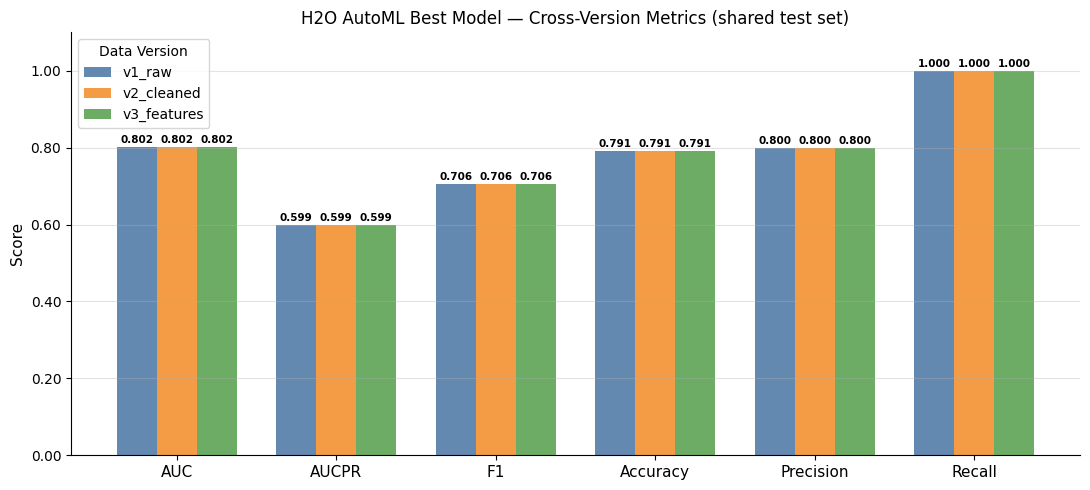

In [9]:
plot_metrics = ['AUC', 'AUCPR', 'F1', 'Accuracy', 'Precision', 'Recall']
versions     = list(summary_df.index)
colors       = ['#4e79a7', '#f28e2b', '#59a14f']
x            = np.arange(len(plot_metrics))
width        = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (ver, color) in enumerate(zip(versions, colors)):
    vals = summary_df.loc[ver, plot_metrics].values.astype(float)
    bars = ax.bar(x + i*width, vals, width, label=ver, color=color, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(plot_metrics, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('H2O AutoML Best Model — Cross-Version Metrics (shared test set)', fontsize=12)
ax.legend(title='Data Version', fontsize=10)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.grid(axis='y', alpha=0.35)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_version_bar.png', dpi=150)
plt.show()

### 8b. ROC Curves — All Three Best Models Overlaid

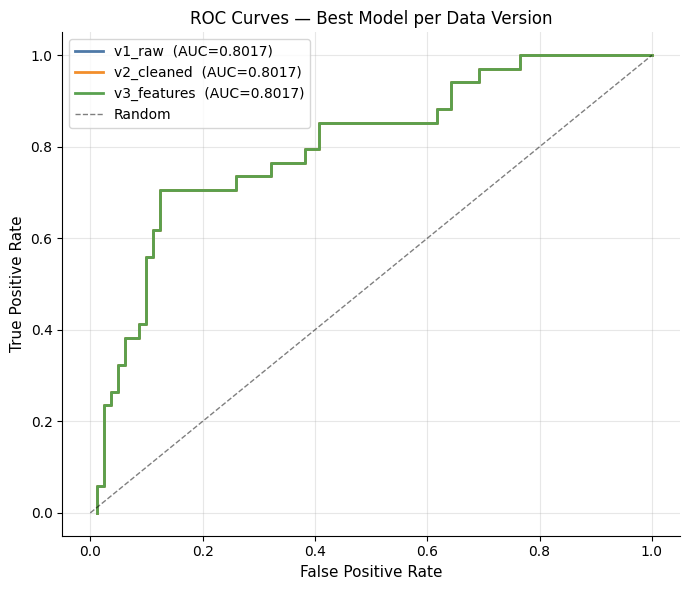

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
colors  = ['#4e79a7', '#f28e2b', '#59a14f']

for (ver, res), color in zip(results.items(), colors):
    perf = res['perf']
    # fprs/tprs are plain Python lists — convert to numpy arrays
    fpr = np.array(perf.fprs)
    tpr = np.array(perf.tprs)
    auc = summary_df.loc[ver, 'AUC']
    ax.plot(fpr, tpr, label=f'{ver}  (AUC={auc})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Best Model per Data Version', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150)
plt.show()

### 8c. Confusion Matrices — Side by Side

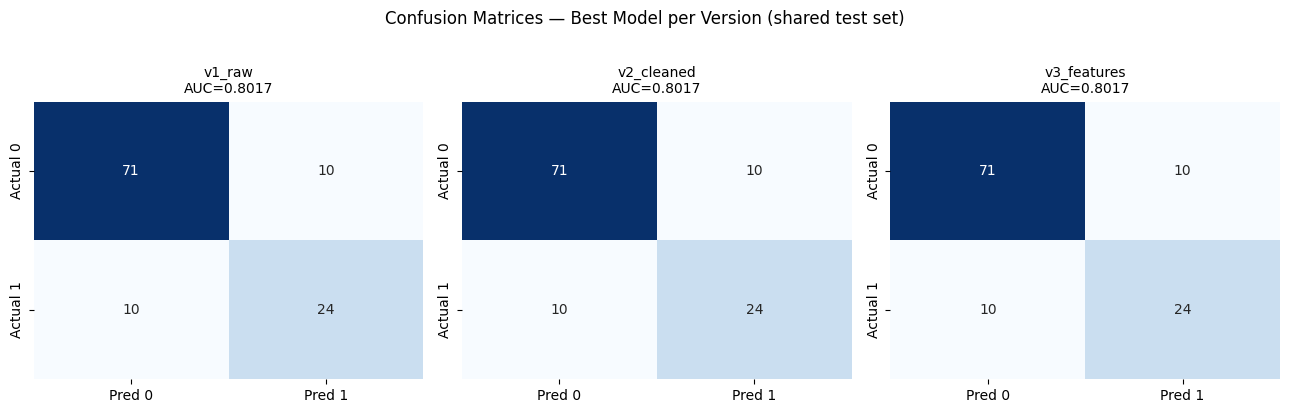

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (ver, res) in zip(axes, results.items()):
    # H2O ConfusionMatrix.table is an H2OTwoDimTable
    # cell_values rows: [label, col0, col1, 'Error', 'Rate']
    # rows 0 = class 0, row 1 = class 1, row 2 = Total
    cv  = res['perf'].confusion_matrix().table.cell_values
    tn  = int(float(cv[0][1]))   # actual=0, pred=0
    fp  = int(float(cv[0][2]))   # actual=0, pred=1
    fn  = int(float(cv[1][1]))   # actual=1, pred=0
    tp  = int(float(cv[1][2]))   # actual=1, pred=1
    cm  = np.array([[tn, fp], [fn, tp]])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['Actual 0','Actual 1'],
                cbar=False)
    auc = summary_df.loc[ver, 'AUC']
    ax.set_title(f'{ver}\nAUC={auc}', fontsize=10)

plt.suptitle('Confusion Matrices — Best Model per Version (shared test set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance per Version

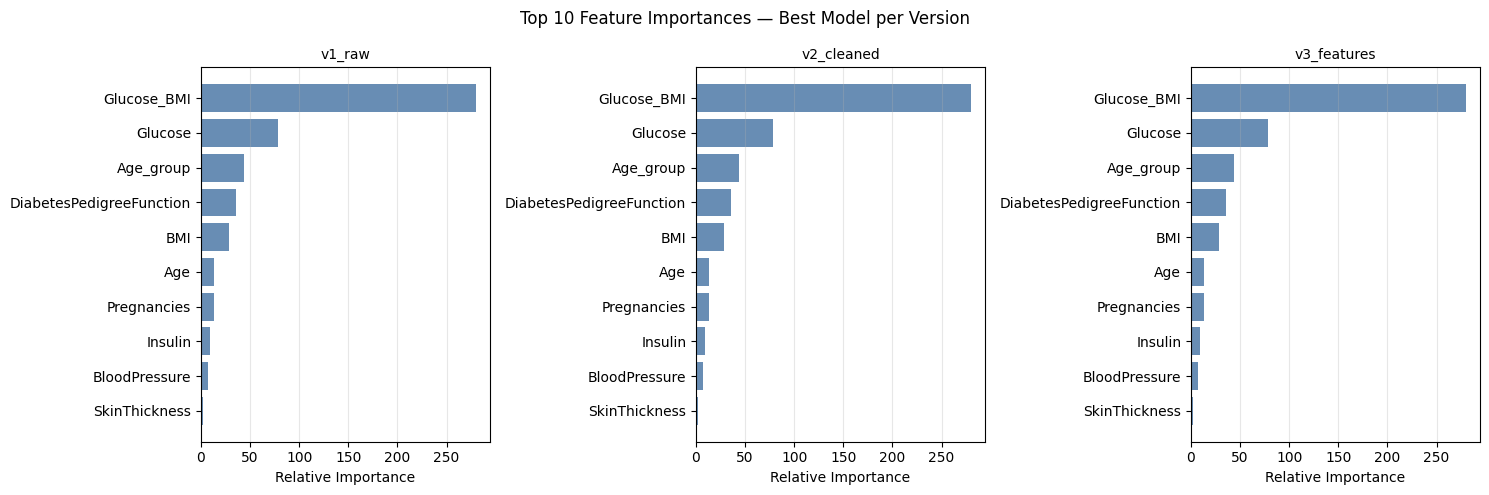

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (ver, res) in zip(axes, results.items()):
    leader = res['aml'].leader
    try:
        fi = leader.varimp(use_pandas=True).head(10)
        ax.barh(fi['variable'][::-1], fi['relative_importance'][::-1],
                color='#4e79a7', alpha=0.85)
        ax.set_title(ver, fontsize=10)
        ax.set_xlabel('Relative Importance')
        ax.grid(axis='x', alpha=0.3)
    except Exception:
        ax.text(0.5, 0.5, 'Stacked Ensemble\n(see base learners)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(ver, fontsize=10)

plt.suptitle('Top 10 Feature Importances — Best Model per Version', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150)
plt.show()

## 10. Save Best Models

In [13]:
for ver, res in results.items():
    path = h2o.save_model(
        model=res['aml'].leader,
        path=str(OUTPUT_DIR / f'best_model_{ver}'),
        force=True,
    )
    print(f'[{ver}] saved -> {path}')

[v1_raw] saved -> /app/h2o_automl_results/best_model_v1_raw/GBM_1_AutoML_1_20260525_193556
[v2_cleaned] saved -> /app/h2o_automl_results/best_model_v2_cleaned/GBM_1_AutoML_2_20260525_193800
[v3_features] saved -> /app/h2o_automl_results/best_model_v3_features/GBM_1_AutoML_3_20260525_194002
